In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit
import random
import openpyxl

# Step 1: Load and preprocess the data
# df = pd.read_excel(r'../data.xlsx', sheet_name='Sheet3')
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

# Define features and target
# X = df[['AGE', 'PC', 'PC_TYPE','FA', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
#        'SLUMP', 'VOID', 'TOTAL_BINDER', 'w/b', 'b/a','SCM%','CAGG','FAGG','FA%','SS%','SF%']].values
X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

y = df['fc (MPa)'].values

# Step 2: Define the curve fitting function
def fc_model(X, a, b, e, d):
    AGE = X[:, 0]
    wb = X[:, -7]  # w/b should be the last feature (index -1)
    
    # Equation: fc = (a * log(AGE) + b) * (e * AGE^d)^(-wb)
    fc_pred = (a * np.log(AGE) + b) * (e * AGE ** d) ** (-wb)
    
    return fc_pred

# Initial guesses for parameters a, b, e, d
initial_guess = [1.0, 1.0, 1.0, 1.0] 

# Step 3: Fit the model to obtain parameters
params, covariance = curve_fit(fc_model, X, y, p0=initial_guess)

# Extract fitted parameters
a, b, e, d = params

print(a,b,e,d)

/Users/zhangtianjie/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


40.49665408379565 15.292027565616022 6.49049168852657 0.36000933143908614


/var/folders/m1/ws2562m105bdpyh7s345x7cw0000gn/T/ipykernel_36978/2336898981.py:33: RuntimeWarning: invalid value encountered in power
  fc_pred = (a * np.log(AGE) + b) * (e * AGE ** d) ** (-wb)


In [7]:


# Step 4: Prepare the data for PyTorch model
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Scale the target variable y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y_scaled = torch.tensor(y_scaled, dtype=torch.float32).view(-1, 1)

# Split the data into training and test sets
Xtrain, Xtest, ytrain_scaled, ytest_scaled = train_test_split(X, y_scaled, train_size=0.85, random_state=42)

# Step 5: Define the PyTorch neural network model
class RegressionModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(RegressionModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Step 6: Custom loss function using the fitted parameters
def custom_loss(outputs, targets, inputs, a, b, e, d):
    mse_loss = nn.MSELoss()(outputs, targets)
    
    # Extract features needed for the fitted equation
    AGE = inputs[:, 0]  # AGE is the first feature
    wb = inputs[:, -7]  
    # Clamp AGE to avoid log of zero or negative numbers
    AGE = torch.clamp(AGE, min=1e-6)
    
    # Compute the fitted equation: fc = (a * log(AGE) + b) * (e * AGE^d)^(-wb)
    fc_pred = (a * torch.log(AGE) + b) * (e * torch.pow(AGE, d)) ** (-wb)
    
    # Calculate the residual between ANN predicted outputs and fitted_fc
    residual = torch.abs(outputs - fc_pred.unsqueeze(1))
    
    # Replace any NaNs in the residual with 0.0
    residual = torch.nan_to_num(residual, nan=0.0, posinf=1e10, neginf=-1e10)
    
    # Normalize residual by comparing its mean square with the MSE
    mean_square_residual = torch.mean(residual ** 2)
    if mean_square_residual.item() > 0:  # Avoid division by zero
        residual_normalized = residual * torch.sqrt(mse_loss / mean_square_residual)
    else:
        residual_normalized = residual  # In case the residual is exactly zero
    
    # Combine MSE loss and the normalized residual
    total_loss = 0.5 * mse_loss + 0.5 * torch.mean(residual_normalized)
    
    return total_loss

# Step 7: Training function
def train_model(model, optimizer, Xtrain, ytrain, epochs=300, batch_size=8, a=None, b=None, e=None, d=None):
    dataset = torch.utils.data.TensorDataset(Xtrain, ytrain)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(epochs):
        model.train()
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = custom_loss(outputs, targets, inputs, a, b, e, d)
            loss.backward()
            optimizer.step()

# Function to evaluate the model
def evaluate_model(model, Xtrain, ytrain, Xtest, ytest):
    model.eval()
    with torch.no_grad():
        ytrain_pred_scaled = model(Xtrain)
        ytest_pred_scaled = model(Xtest)
        
    # Inverse transform the scaled predictions back to the original scale
    ytrain_pred = y_scaler.inverse_transform(ytrain_pred_scaled.numpy())
    ytest_pred = y_scaler.inverse_transform(ytest_pred_scaled.numpy())
    
    # Inverse transform the actual scaled targets for comparison
    ytrain_actual = y_scaler.inverse_transform(ytrain.numpy())
    ytest_actual = y_scaler.inverse_transform(ytest.numpy())
    
    # Calculate performance metrics
    train_r2 = r2_score(ytrain_actual, ytrain_pred)
    test_r2 = r2_score(ytest_actual, ytest_pred)
    rmse = mean_squared_error(ytest_actual, ytest_pred) ** 0.5
    mae = mean_absolute_error(ytest_actual, ytest_pred)
    
    return train_r2, test_r2, rmse, mae

# Step 8: Randomly adjust model structure, run it 100 times, and collect metrics
results = []

# Create a folder for saving models if it doesn't exist
model_folder = 'KINN_saved_models'
if not os.path.exists(model_folder):
    os.makedirs(model_folder)

for i in range(100):
    print('epoch:',i)
    # Randomly generate model parameters
    layers = 2  # Between 1 and 5 layers
    neurons = 52  # Between 10 and 100 neurons per layer
    learn_rate = 0.0007652946585818769  # Learning rate between 0.0001 and 0.01
    
    # Create the model with random parameters
    model = RegressionModel(Xtrain.shape[1], layers, neurons)
    optimizer = optim.Adam(model.parameters(), lr=learn_rate)
    
    # Train the model
    train_model(model, optimizer, Xtrain, ytrain_scaled, a=a, b=b, e=e, d=d)
    
    # Evaluate the model
    train_r2, test_r2, rmse, mae = evaluate_model(model, Xtrain, ytrain_scaled, Xtest, ytest_scaled)
    
    # Save results
    results.append({
        'Run': i + 1,
        'Layers': layers,
        'Neurons': neurons,
        'Learning Rate': learn_rate,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'RMSE': rmse,
        'MAE': mae
    })
    
    # Save the model state
    model_path = os.path.join(model_folder, f'model_run_{i+1}.pt')
    torch.save(model.state_dict(), model_path)
    print(f'Model {i+1} saved to {model_path}')

# Step 9: Save the evaluation metrics to an Excel file
results_df = pd.DataFrame(results)
results_df.to_excel('model_evaluation_metrics.xlsx', index=False)

print(f'Metrics saved to model_evaluation_metrics.xlsx')


epoch: 0
Model 1 saved to KINN_saved_models/model_run_1.pt
epoch: 1
Model 2 saved to KINN_saved_models/model_run_2.pt
epoch: 2
Model 3 saved to KINN_saved_models/model_run_3.pt
epoch: 3
Model 4 saved to KINN_saved_models/model_run_4.pt
epoch: 4
Model 5 saved to KINN_saved_models/model_run_5.pt
epoch: 5
Model 6 saved to KINN_saved_models/model_run_6.pt
epoch: 6
Model 7 saved to KINN_saved_models/model_run_7.pt
epoch: 7
Model 8 saved to KINN_saved_models/model_run_8.pt
epoch: 8
Model 9 saved to KINN_saved_models/model_run_9.pt
epoch: 9
Model 10 saved to KINN_saved_models/model_run_10.pt
epoch: 10
Model 11 saved to KINN_saved_models/model_run_11.pt
epoch: 11
Model 12 saved to KINN_saved_models/model_run_12.pt
epoch: 12
Model 13 saved to KINN_saved_models/model_run_13.pt
epoch: 13
Model 14 saved to KINN_saved_models/model_run_14.pt
epoch: 14
Model 15 saved to KINN_saved_models/model_run_15.pt
epoch: 15
Model 16 saved to KINN_saved_models/model_run_16.pt
epoch: 16
Model 17 saved to KINN_sav

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

# Step 4: Prepare the data for PyTorch model
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Scale the target variable y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

# Get the standard deviation of the target variable (y)
y_std = y_scaler.scale_[0]  # This is the standard deviation used in scaling y

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y_scaled = torch.tensor(y_scaled, dtype=torch.float32).view(-1, 1)

# Split the data into training and test sets
Xtrain, Xtest, ytrain_scaled, ytest_scaled = train_test_split(X, y_scaled, train_size=0.85, random_state=42)

# Define the PyTorch neural network model (unchanged)
class RegressionModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(RegressionModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Custom loss function using the fitted parameters (unchanged)
def custom_loss(outputs, targets, inputs, a, b, e, d):
    mse_loss = nn.MSELoss()(outputs, targets)
    AGE = inputs[:, 0]  # AGE is the first feature
    wb = inputs[:, -7]  
    AGE = torch.clamp(AGE, min=1e-6)
    fc_pred = (a * torch.log(AGE) + b) * (e * torch.pow(AGE, d)) ** (-wb)
    residual = torch.abs(outputs - fc_pred.unsqueeze(1))
    residual = torch.nan_to_num(residual, nan=0.0, posinf=1e10, neginf=-1e10)
    mean_square_residual = torch.mean(residual ** 2)
    if mean_square_residual.item() > 0:
        residual_normalized = residual * torch.sqrt(mse_loss / mean_square_residual)
    else:
        residual_normalized = residual
    total_loss = 0.5 * mse_loss + 0.5 * torch.mean(residual_normalized)
    return total_loss

# Training function (unchanged)
def train_model(model, optimizer, Xtrain, ytrain, epochs=300, batch_size=8, a=None, b=None, e=None, d=None):
    dataset = torch.utils.data.TensorDataset(Xtrain, ytrain)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(epochs):
        model.train()
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = custom_loss(outputs, targets, inputs, a, b, e, d)
            loss.backward()
            optimizer.step()

# Function to evaluate the model and compute scaled metrics
def evaluate_model(model, Xtrain, ytrain, Xtest, ytest, y_std):
    model.eval()
    with torch.no_grad():
        ytrain_pred_scaled = model(Xtrain)
        ytest_pred_scaled = model(Xtest)
        
    # Inverse transform the scaled predictions back to the original scale
    ytrain_pred = y_scaler.inverse_transform(ytrain_pred_scaled.numpy())
    ytest_pred = y_scaler.inverse_transform(ytest_pred_scaled.numpy())
    
    # Inverse transform the actual scaled targets for comparison
    ytrain_actual = y_scaler.inverse_transform(ytrain.numpy())
    ytest_actual = y_scaler.inverse_transform(ytest.numpy())
    
    # Calculate performance metrics (unscaled)
    train_r2 = r2_score(ytrain_actual, ytrain_pred)
    test_r2 = r2_score(ytest_actual, ytest_pred)
    rmse = mean_squared_error(ytest_actual, ytest_pred) ** 0.5
    mae = mean_absolute_error(ytest_actual, ytest_pred)
    
    # Calculate scaled RMSE and MAE by dividing by the standard deviation
    scaled_rmse = rmse / y_std
    scaled_mae = mae / y_std
    
    return train_r2, test_r2, rmse, mae, scaled_rmse, scaled_mae

# Run the model 100 times and save results (including scaled metrics)
results = []
model_folder = 'KINN_saved_models_scaled'
if not os.path.exists(model_folder):
    os.makedirs(model_folder)

for i in range(100):
    print('Run:', i + 1)
    layers = 2
    neurons = 52
    learn_rate = 0.0007652946585818769
    
    # Create and train the model
    model = RegressionModel(Xtrain.shape[1], layers, neurons)
    optimizer = optim.Adam(model.parameters(), lr=learn_rate)
    train_model(model, optimizer, Xtrain, ytrain_scaled, a=a, b=b, e=e, d=d)
    
    # Evaluate the model
    train_r2, test_r2, rmse, mae, scaled_rmse, scaled_mae = evaluate_model(
        model, Xtrain, ytrain_scaled, Xtest, ytest_scaled, y_std)
    
    # Save results including scaled metrics
    results.append({
        'Run': i + 1,
        'Layers': layers,
        'Neurons': neurons,
        'Learning Rate': learn_rate,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'RMSE': rmse,
        'MAE': mae,
        'Scaled RMSE': scaled_rmse,
        'Scaled MAE': scaled_mae
    })
    
    # Save the model state
    model_path = os.path.join(model_folder, f'model_run_{i+1}.pt')
    torch.save(model.state_dict(), model_path)
    print(f'Model {i+1} saved to {model_path}')

# Save the evaluation metrics to an Excel file
results_df = pd.DataFrame(results)
results_df.to_excel('model_evaluation_metrics_with_scaled.xlsx', index=False)

print(f'Metrics saved to model_evaluation_metrics_with_scaled.xlsx')


Run: 1
Model 1 saved to KINN_saved_models_scaled/model_run_1.pt
Run: 2
Model 2 saved to KINN_saved_models_scaled/model_run_2.pt
Run: 3
Model 3 saved to KINN_saved_models_scaled/model_run_3.pt
Run: 4
Model 4 saved to KINN_saved_models_scaled/model_run_4.pt
Run: 5
Model 5 saved to KINN_saved_models_scaled/model_run_5.pt
Run: 6
Model 6 saved to KINN_saved_models_scaled/model_run_6.pt
Run: 7
Model 7 saved to KINN_saved_models_scaled/model_run_7.pt
Run: 8
Model 8 saved to KINN_saved_models_scaled/model_run_8.pt
Run: 9
Model 9 saved to KINN_saved_models_scaled/model_run_9.pt
Run: 10
Model 10 saved to KINN_saved_models_scaled/model_run_10.pt
Run: 11
Model 11 saved to KINN_saved_models_scaled/model_run_11.pt
Run: 12
Model 12 saved to KINN_saved_models_scaled/model_run_12.pt
Run: 13
Model 13 saved to KINN_saved_models_scaled/model_run_13.pt
Run: 14
Model 14 saved to KINN_saved_models_scaled/model_run_14.pt
Run: 15
Model 15 saved to KINN_saved_models_scaled/model_run_15.pt
Run: 16
Model 16 saved

## SHAP

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

Y = df['fc (MPa)'].values

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)

# Define features
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']
Xtrain_df = pd.DataFrame(Xtrain, columns=features)
Xtest_df = pd.DataFrame(Xtest, columns=features)

class RegressionModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(RegressionModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Custom loss function
def custom_loss(outputs, targets, inputs, a, b, e, d):
    mse_loss = nn.MSELoss()(outputs, targets)
    AGE = inputs[:, 0]  # AGE is the first feature
    wb = inputs[:, -7]  
    AGE = torch.clamp(AGE, min=1e-6)
    fc_pred = (a * torch.log(AGE) + b) * (e * torch.pow(AGE, d)) ** (-wb)
    residual = torch.abs(outputs - fc_pred.unsqueeze(1))
    residual = torch.nan_to_num(residual, nan=0.0, posinf=1e10, neginf=-1e10)
    mean_square_residual = torch.mean(residual ** 2)
    if mean_square_residual.item() > 0:
        residual_normalized = residual * torch.sqrt(mse_loss / mean_square_residual)
    else:
        residual_normalized = residual
    total_loss = 0.5 * mse_loss + 0.5 * torch.mean(residual_normalized)
    return total_loss

# Training function
def train_model(model, optimizer, Xtrain, ytrain, epochs=300, batch_size=8, a=None, b=None, e=None, d=None):
    dataset = torch.utils.data.TensorDataset(Xtrain, ytrain)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(epochs):
        model.train()
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = custom_loss(outputs, targets, inputs, a, b, e, d)
            loss.backward()
            optimizer.step()

# Hyperparameters
layers = 2  # Number of layers between 2 and 5
neurons = 52  # Number of neurons per layer
learning_rate = 0.0007652946585818769  # Fixed learning rate

# Initialize model
model = RegressionModel(Xtrain.shape[1], layers, neurons)

# Move model and data to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
Xtrain_tensor = torch.FloatTensor(Xtrain).to(device)
ytrain_tensor = torch.FloatTensor(ytrain).to(device)
Xtest_tensor = torch.FloatTensor(Xtest).to(device)

# Define custom parameters (make sure to set these)
a = 40.49665408379565
b = 15.292027565616022
e = 6.49049168852657
d = 0.36000933143908614

# Train the model
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
train_model(model, optimizer, Xtrain_tensor, ytrain_tensor, a=a, b=b, e=e, d=d)

# SHAP analysis
model.eval()  # Set model to evaluation mode
explainer = shap.DeepExplainer(model, Xtrain_tensor)  # Use DeepExplainer for PyTorch models
shap_values = explainer.shap_values(Xtest_tensor)  # Calculate SHAP values for the test data


Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
Using a target size (torch.Size([4])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.


KeyboardInterrupt: 

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

Y = df['fc (MPa)'].values

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)

# Define features
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']
Xtrain_df = pd.DataFrame(Xtrain, columns=features)
Xtest_df = pd.DataFrame(Xtest, columns=features)

class RegressionModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(RegressionModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Custom loss function
def custom_loss(outputs, targets, inputs, a, b, e, d):
    outputs = outputs.squeeze()  # Remove the extra dimension
    mse_loss = nn.MSELoss()(outputs, targets)
    AGE = inputs[:, 0]  # AGE is the first feature
    wb = inputs[:, -7]  
    AGE = torch.clamp(AGE, min=1e-6)
    fc_pred = (a * torch.log(AGE) + b) * (e * torch.pow(AGE, d)) ** (-wb)
    residual = torch.abs(outputs - fc_pred.unsqueeze(1))
    residual = torch.nan_to_num(residual, nan=0.0, posinf=1e10, neginf=-1e10)
    mean_square_residual = torch.mean(residual ** 2)
    if mean_square_residual.item() > 0:
        residual_normalized = residual * torch.sqrt(mse_loss / mean_square_residual)
    else:
        residual_normalized = residual
    total_loss = 0.5 * mse_loss + 0.5 * torch.mean(residual_normalized)
    return total_loss

# Training function
def train_model(model, optimizer, Xtrain, ytrain, epochs=300, batch_size=8, a=None, b=None, e=None, d=None):
    dataset = torch.utils.data.TensorDataset(Xtrain, ytrain)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()  # Squeeze to match dimensions
            loss = custom_loss(outputs, targets, inputs, a, b, e, d)
            loss.backward()
            optimizer.step()

# Hyperparameters
layers = 2  # Number of layers between 2 and 5
neurons = 52  # Number of neurons per layer
learning_rate = 0.00076  # Fixed learning rate

# Initialize model
model = RegressionModel(Xtrain.shape[1], layers, neurons)

# Move model and data to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
Xtrain_tensor = torch.FloatTensor(Xtrain).to(device)
ytrain_tensor = torch.FloatTensor(ytrain).to(device)
Xtest_tensor = torch.FloatTensor(Xtest).to(device)

# Define custom parameters
a = 40.5
b = 15.3
e = 6.5
d = 0.36

# Train the model
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
train_model(model, optimizer, Xtrain_tensor, ytrain_tensor, a=a, b=b, e=e, d=d)

# SHAP analysis
model.eval()  # Set model to evaluation mode
explainer = shap.DeepExplainer(model, Xtrain_tensor)  # Use DeepExplainer for PyTorch models
shap_values = explainer.shap_values(Xtest_tensor)  # Calculate SHAP values for the test data

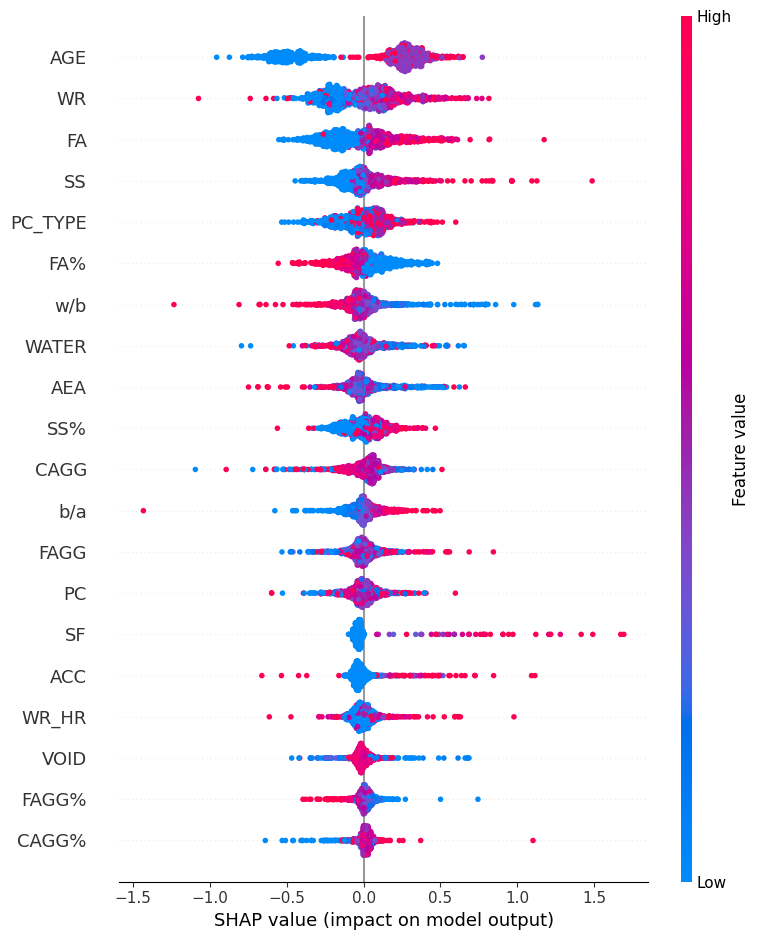

In [10]:
# Optional: Visualize SHAP values
shap.initjs()
shap.summary_plot(shap_values, Xtest_tensor.cpu().numpy(), feature_names=features, show=False)
plt.savefig('KINN_summary_plot1.png', bbox_inches='tight', dpi=300)  # You can change the filename and format as needed